#**Projeto Aprendizagem de Máquina - 2025.2**

Grupo:
* Jéssica Maria
* Vinícius José



---



Este projeto abordará um problema de **Regressão**.

**Escolha da Base de Dados:**

utiliza dados históricos de vazões diárias (em m³/s) de três importantes usinas hidrelétricas brasileiras: Ilha Solteira, Jupiá e Passo Real. Os dados cobrem um longo período, de 1931 a 2016, permitindo uma análise temporal robusta. O estudo de vazões é fundamental para o planejamento energético nacional, gestão de recursos hídricos e previsão de eventos extremos (secas ou cheias).

O objetivo central é **prever um valor numérico contínuo**: a vazão diária (em m³/s) de uma usina hidrelétrica.


---






# Dependências


## instalação

In [ ]:
!pip install pdfplumber==0.11.0 \
             matplotlib==3.9.2 \
             seaborn==0.13.2 \
             pandas==2.2.3 \
             numpy==2.1.2 \
             scikit-learn==1.5.2

##Importação

In [ ]:
print("importando dependências")

# Manipulação e análise de dados
import pandas as pd
import numpy as np
import re
import io

# Leitura de PDFs
import pdfplumber


# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações gerais
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("crest")

#conexão com google drive
from google.colab import drive
drive.mount('/content/drive')


importando dependências
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Carregamento da Base de Dados


In [ ]:
def extrair_vazoes_pdf(caminho_pdf, nome_usina):
    """
    Lê um PDF de vazões diárias e retorna um DataFrame com colunas ['Data', 'Vazao', 'Usina'].
    """
    dados = []

    with pdfplumber.open(caminho_pdf) as pdf:
        for pagina in pdf.pages:
            texto = pagina.extract_text()
            if not texto:
                continue
            linhas = texto.split('\n')
            for linha in linhas:
                match = re.match(r"(\d{1,2}/[a-z]{3}/\d{4})\s+(\d+)", linha, re.IGNORECASE)
                if match:
                    data = match.group(1)
                    vazao = int(match.group(2))
                    dados.append((data, vazao))

    df = pd.DataFrame(dados, columns=["Data", "Vazao"])
    df["Data"] = pd.to_datetime(df["Data"], format="%d/%b/%Y", errors="coerce")
    df["Usina"] = nome_usina

    df["Vazao"] = pd.to_numeric(df["Vazao"], errors='coerce')

    df_limpo = df.dropna(subset=["Data"])
    return df_limpo

In [ ]:
#definindo caminho dos arquivos
caminho_ilha_solteira = "/content/drive/MyDrive/Dados_Vazao/Vazoes_Diarias_1931_2016_RESUMIDA_ILHA_SOLTEIRA.pdf"
caminho_jupia = "/content/drive/MyDrive/Dados_Vazao/Vazoes_Diarias_1931_2016_RESUMIDA_JUPIA.pdf"
caminho_passo_real = "/content/drive/MyDrive/Dados_Vazao/Vazoes_Diarias_1931_2016_RESUMIDA_PASSO_REAL.pdf"


#execução
ilha_solteira = extrair_vazoes_pdf(caminho_ilha_solteira, "Ilha Solteira")
jupia = extrair_vazoes_pdf(caminho_jupia, "Jupiá")
passo_real = extrair_vazoes_pdf(caminho_passo_real, "Passo Real")


In [ ]:
#Vizualização
display(ilha_solteira.head(), jupia.head(), passo_real.head())

,Data,Vazao,Usina
0,1931-01-01,13180,Ilha Solteira
1,1931-01-02,13077,Ilha Solteira
2,1931-01-03,12769,Ilha Solteira
3,1931-01-04,12564,Ilha Solteira
4,1931-01-05,12400,Ilha Solteira


,Data,Vazao,Usina
0,1931-01-01,16060,Jupiá
1,1931-01-02,15935,Jupiá
2,1931-01-03,15559,Jupiá
3,1931-01-04,15309,Jupiá
4,1931-01-05,15109,Jupiá


,Data,Vazao,Usina
28,1939-03-01,130,Passo Real
29,1939-03-02,103,Passo Real
30,1939-03-03,83,Passo Real
31,1939-03-04,83,Passo Real
32,1939-03-05,94,Passo Real


# Análise Exploratória dos Dados

In [ ]:
# Combina todas as usinas
df_vazoes = pd.concat([ilha_solteira, jupia, passo_real], ignore_index=True)

# Ordena por data
df_vazoes = df_vazoes.sort_values(by=["Usina", "Data"]).reset_index(drop=True)

# Cria colunas de ano e mês
df_vazoes["Ano"] = df_vazoes["Data"].dt.year
df_vazoes["Mes"] = df_vazoes["Data"].dt.month

# Exibe amostra
df_vazoes.head()

,Data,Vazao,Usina,Ano,Mes
0,1931-01-01,13180,Ilha Solteira,1931,1
1,1931-01-02,13077,Ilha Solteira,1931,1
2,1931-01-03,12769,Ilha Solteira,1931,1
3,1931-01-04,12564,Ilha Solteira,1931,1
4,1931-01-05,12400,Ilha Solteira,1931,1


In [ ]:
# Estatísticas por usina
estatisticas = df_vazoes.groupby("Usina")["Vazao"].describe()
print(estatisticas)

print("\n Contagem de Valores Nulos por Coluna")
print(df_vazoes.isnull().sum())


                 count         mean          std     min      25%     50%  \
Usina                                                                       
Ilha Solteira  13158.0  5729.050236  3506.168686  1493.0  3170.00  4218.0   
Jupiá          13158.0  6949.977732  4063.446305  1978.0  4009.25  5203.5   
Passo Real     11903.0   198.454759   215.654387     3.0    76.00   134.0   

                   75%      max  
Usina                            
Ilha Solteira  7818.25  22519.0  
Jupiá          9398.00  25387.0  
Passo Real      239.00   2937.0  

 Contagem de Valores Nulos por Coluna
Data     0
Vazao    0
Usina    0
Ano      0
Mes      0
dtype: int64


Reamostrando dados por média anual...

Amostra dos dados anuais (deve mostrar vários anos):


/tmp/ipython-input-3534382134.py:6: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_anual = df_plot_limpo.groupby('Usina')['Vazao'].resample('Y').mean().reset_index()


,Usina,Data,Vazao
0,Ilha Solteira,1931-12-31,7351.542484
1,Ilha Solteira,1932-12-31,5499.601307
2,Ilha Solteira,1933-12-31,5148.300654
3,Ilha Solteira,1934-12-31,3693.692810
4,Ilha Solteira,1935-12-31,5950.483660


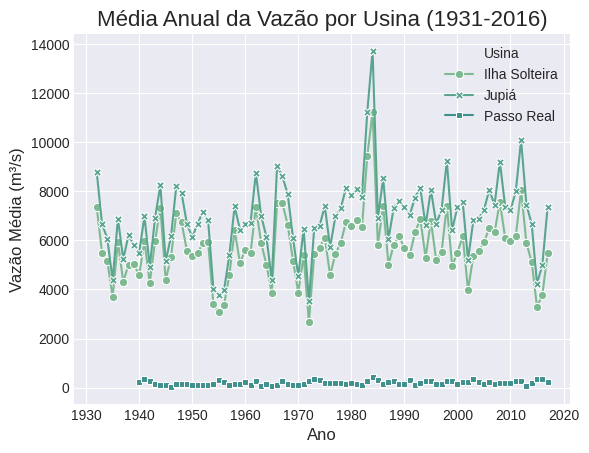

In [ ]:
#Vizualização
df_plot = df_vazoes.set_index('Data')
df_plot['Vazao'] = pd.to_numeric(df_plot['Vazao'], errors='coerce')
df_plot_limpo = df_plot.dropna(subset=['Vazao'])
print("Reamostrando dados por média anual...")
df_anual = df_plot_limpo.groupby('Usina')['Vazao'].resample('Y').mean().reset_index()

print("\nAmostra dos dados anuais (deve mostrar vários anos):")
display(df_anual.head())


#plotagem do gráfico

sns.lineplot(
        data=df_anual,
        x='Data',     # Coluna de Data (agora contém os anos)
        y='Vazao',    # Coluna de Vazão Média
        hue='Usina',  # Linhas com cores diferentes para cada 'Usina'
        style='Usina',# Estilos de linha diferentes
        markers=True, # Adiciona marcadores em cada ponto (ano)
        dashes=False
    )

plt.title('Média Anual da Vazão por Usina (1931-2016)', fontsize=16)
plt.ylabel('Vazão Média (m³/s)', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.legend(title='Usina', fontsize=10)
plt.grid(True) # Adiciona grade
plt.show() # Exibe o gráfico

# Tratamento dos dados para ML

In [ ]:
from sklearn.preprocessing import MinMaxScaler

#dados em 'df_vazoes' já estão limpos (sem NaNs)

# criar uma cópia para o ML
df_ml = df_vazoes.copy()

#Instanciar o Scaler
scaler = MinMaxScaler()

#Normalização (Escala 0-1) por Grupo
# Aplicamos diretamente na coluna 'Vazao'
print("Normalizando dados por grupo...")
df_ml['Vazao_norm'] = df_ml.groupby('Usina')['Vazao'].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
)

#Engenharia de Features (Lags)
#Problema: Prever a vazão de "hoje" (y) usando a vazão de "ontem" (X)
print("Criando features (lags)...")
df_ml['X_lag_1'] = df_ml.groupby('Usina')['Vazao_norm'].shift(1)
df_ml['y_target'] = df_ml['Vazao_norm']

#Limpeza Final (dos NaNs criados pelo .shift())
print(f"Tamanho antes de dropar NaNs do shift: {len(df_ml)}")


df_final = df_ml.dropna(subset=['X_lag_1'])

print(f"Tamanho após dropar NaNs do shift:  {len(df_final)}")
print("\n--- DataFrame 'df_final' PRONTO PARA O MODELO ---")
display(df_final.head())

Normalizando dados por grupo...
Criando features (lags)...
Tamanho antes de dropar NaNs do shift: 38219
Tamanho após dropar NaNs do shift:  38216

--- DataFrame 'df_final' PRONTO PARA O MODELO ---


,Data,Vazao,Usina,Ano,Mes,Vazao_norm,X_lag_1,y_target
1,1931-01-02,13077,Ilha Solteira,1931,1,0.550937,0.555836,0.550937
2,1931-01-03,12769,Ilha Solteira,1931,1,0.536288,0.550937,0.536288
3,1931-01-04,12564,Ilha Solteira,1931,1,0.526539,0.536288,0.526539
4,1931-01-05,12400,Ilha Solteira,1931,1,0.518739,0.526539,0.518739
5,1931-01-06,11956,Ilha Solteira,1931,1,0.497622,0.518739,0.497622


# Implementação e Treinamento

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Definir as colunas de features (X) e alvo (y)
FEATURE_COLS = ['X_lag_1']
TARGET_COL = 'y_target'

#Criar uma lista de usinas para iterar
usinas = df_final['Usina'].unique()

#Dicionário para guardar os resultados de cada modelo
resultados = {}

#Loop de Treinamento
for usina in usinas:
    print(f"\n--- Processando Usina: {usina} ---")

    # Isolar os dados da usina
    df_usina = df_final[df_final['Usina'] == usina].copy()

    # Definir X e y
    X = df_usina[FEATURE_COLS]
    y = df_usina[TARGET_COL]

    #Split Temporal (80% Treino, 20% Teste)
    #Cortamos pelo tempo.
    split_index = int(len(df_usina) * 0.8)

    X_train = X.iloc[:split_index]
    y_train = y.iloc[:split_index]

    X_test = X.iloc[split_index:]
    y_test = y.iloc[split_index:]

    print(f"  Total de dados: {len(df_usina)}")
    print(f"  Registros de Treino: {len(X_train)} (80%)")
    print(f"  Registros de Teste: {len(X_test)} (20%)")

    #Instanciar o Modelo Base
    #Usamos 5 vizinhos (dias com 'X_lag_1' parecido) para fazer a previsão
    knn_model = KNeighborsRegressor(n_neighbors=5)

    #Treinar o Modelo
    print("  Treinando modelo KNN...")
    knn_model.fit(X_train, y_train)

    #Fazer Previsões
    print("  Fazendo previsões nos dados de teste...")
    y_pred = knn_model.predict(X_test)

    #Avaliar o Modelo
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n  Resultados de Avaliação ({usina}):")
    print(f"  MAE (Erro Médio Absoluto): {mae:.4f}")
    print(f"  MSE (Erro Quadrático Médio): {mse:.4f}")
    print(f"  R² (Coef. de Determinação): {r2:.4f}")

    #Guardar os resultados para plotar
    resultados[usina] = {
        'modelo': knn_model,
        'y_test': y_test,
        'y_pred': y_pred,
        'r2': r2,
        'data_teste': df_usina.iloc[split_index:]['Data'] # Guardar as datas para o gráfico
    }

print("\n--- Treinamento de todos os modelos concluído! ---")


--- Processando Usina: Ilha Solteira ---
  Total de dados: 13157
  Registros de Treino: 10525 (80%)
  Registros de Teste: 2632 (20%)
  Treinando modelo KNN...
  Fazendo previsões nos dados de teste...

  Resultados de Avaliação (Ilha Solteira):
  MAE (Erro Médio Absoluto): 0.0155
  MSE (Erro Quadrático Médio): 0.0012
  R² (Coef. de Determinação): 0.9584

--- Processando Usina: Jupiá ---
  Total de dados: 13157
  Registros de Treino: 10525 (80%)
  Registros de Teste: 2632 (20%)
  Treinando modelo KNN...
  Fazendo previsões nos dados de teste...

  Resultados de Avaliação (Jupiá):
  MAE (Erro Médio Absoluto): 0.0168
  MSE (Erro Quadrático Médio): 0.0013
  R² (Coef. de Determinação): 0.9576

--- Processando Usina: Passo Real ---
  Total de dados: 11902
  Registros de Treino: 9521 (80%)
  Registros de Teste: 2381 (20%)
  Treinando modelo KNN...
  Fazendo previsões nos dados de teste...

  Resultados de Avaliação (Passo Real):
  MAE (Erro Médio Absoluto): 0.0180
  MSE (Erro Quadrático Médi

## Visualização dos Resultados (Previsão vs. Real)

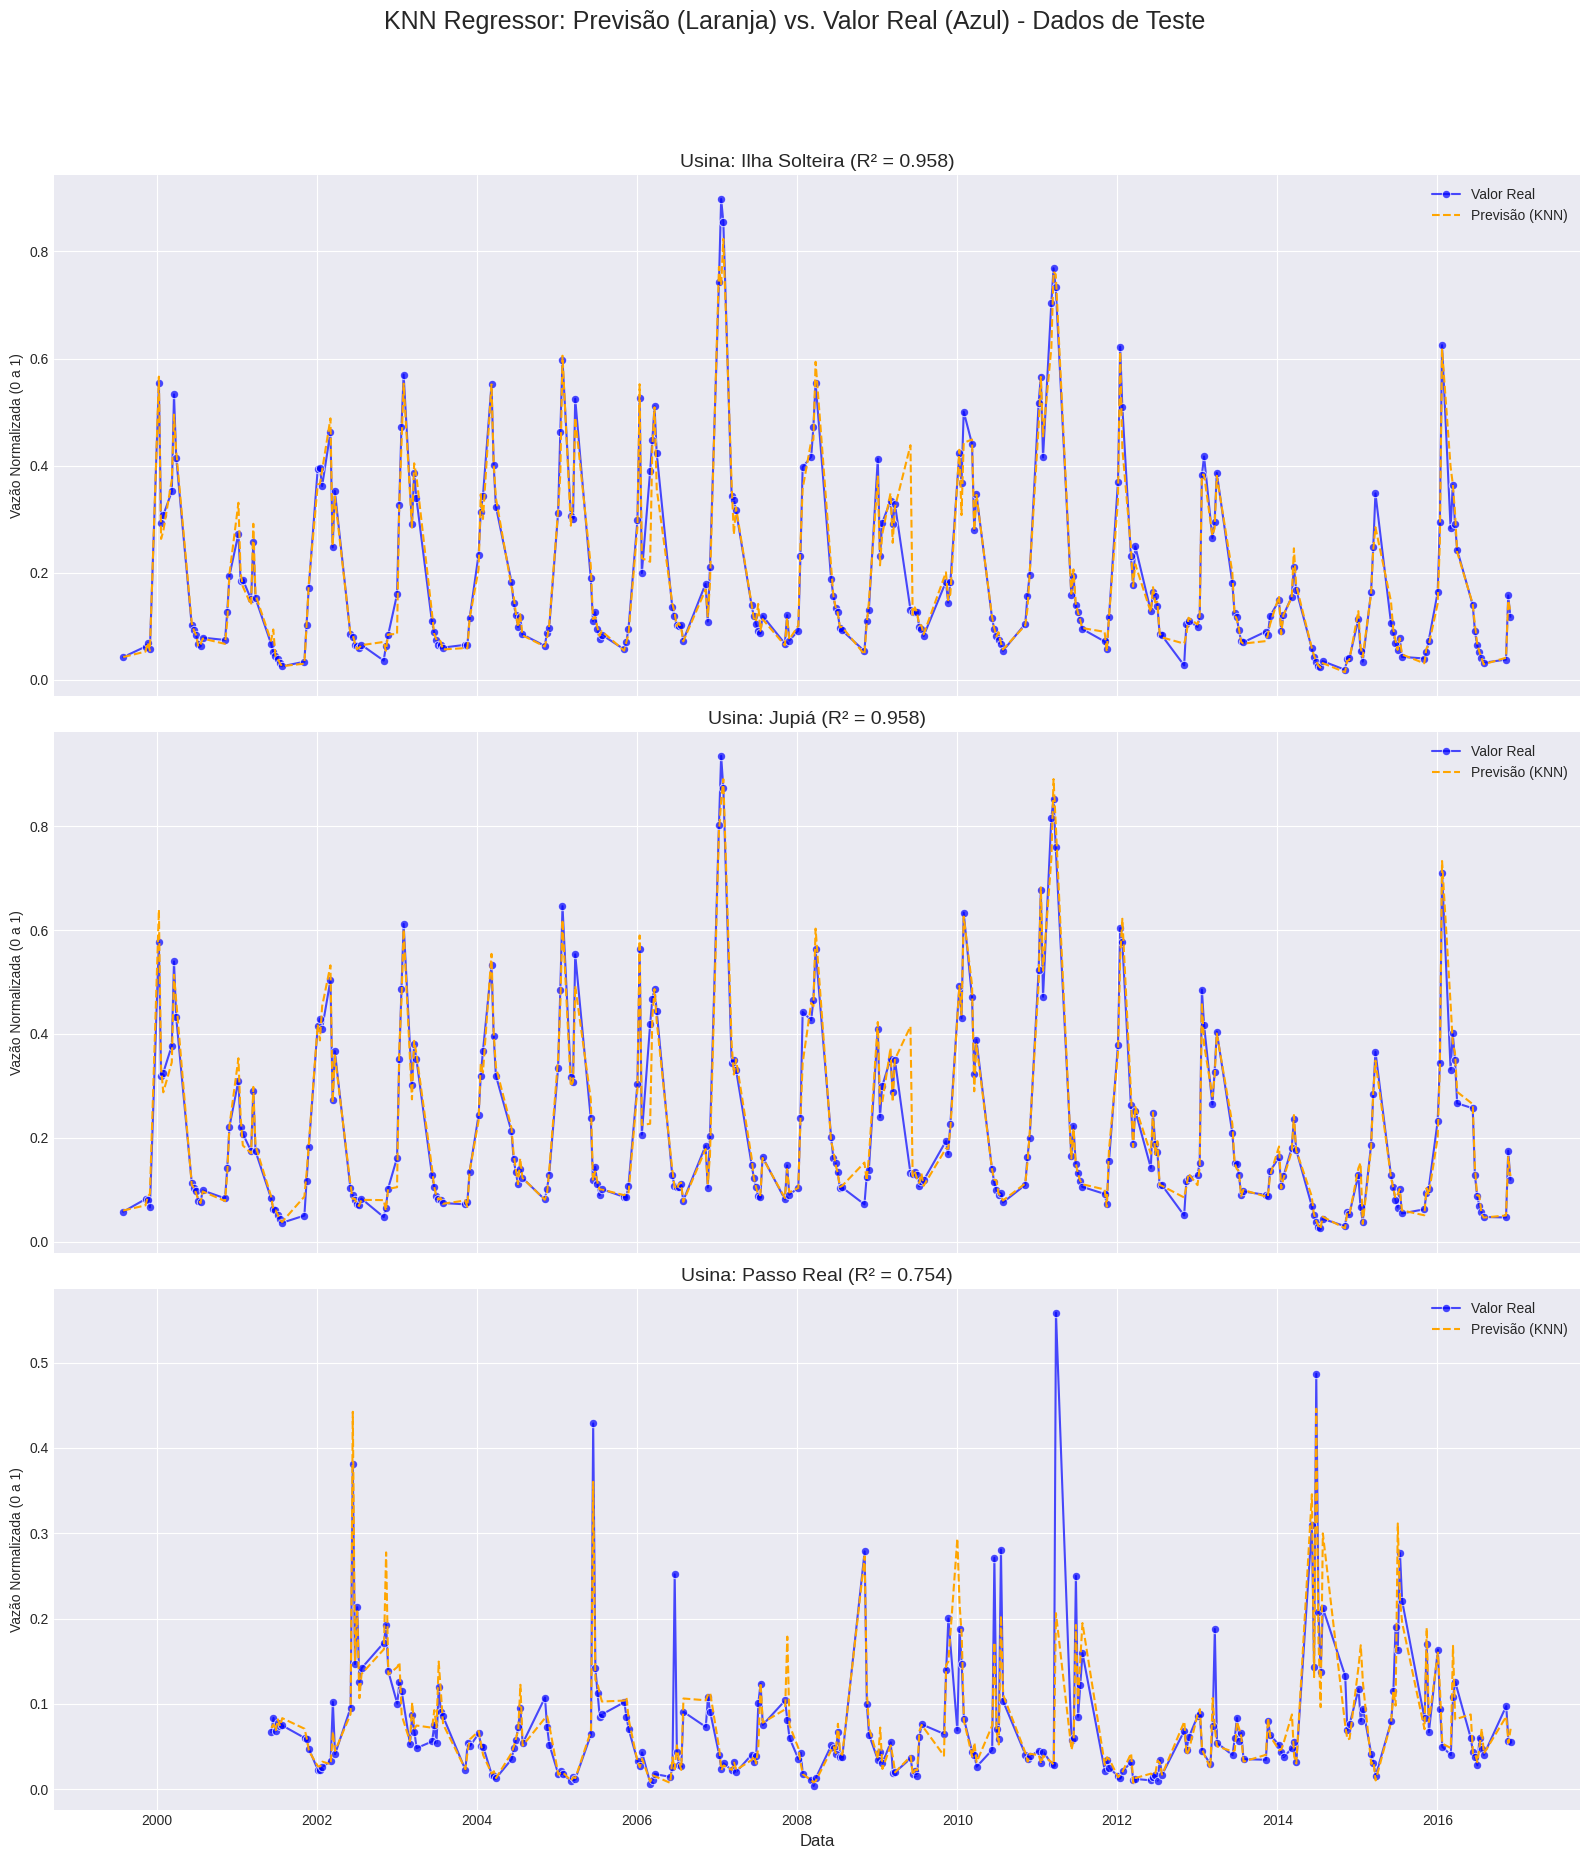

In [ ]:
# Criar subplots (1 para cada usina)
num_usinas = len(usinas)
fig, axes = plt.subplots(nrows=num_usinas, ncols=1, figsize=(16, 6 * num_usinas), sharex=True)

# Garantir que 'axes' seja sempre um array, mesmo se houver 1 usina
if num_usinas == 1:
    axes = [axes]

fig.suptitle('KNN Regressor: Previsão (Laranja) vs. Valor Real (Azul) - Dados de Teste', fontsize=18, y=1.03)

for i, usina in enumerate(usinas):
    ax = axes[i]
    res = resultados[usina]

    # Criar um DataFrame de resultados para plotar
    df_plot = pd.DataFrame({
        'Data': res['data_teste'],
        'Real': res['y_test'],
        'Previsto': res['y_pred']
    })

    # Plotar as duas linhas
    # Usamos .iloc[::10] para plotar apenas 1 a cada 10 pontos (gráfico mais limpo)
    sns.lineplot(data=df_plot.iloc[::10], x='Data', y='Real', label='Valor Real', ax=ax, color='blue', alpha=0.7, marker='o')
    sns.lineplot(data=df_plot.iloc[::10], x='Data', y='Previsto', label='Previsão (KNN)', ax=ax, color='orange', linestyle='--')

    ax.set_title(f'Usina: {usina} (R² = {res["r2"]:.3f})', fontsize=14)
    ax.set_ylabel('Vazão Normalizada (0 a 1)')
    ax.legend()
    ax.grid(True)

plt.xlabel('Data', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# metricas estatisticas

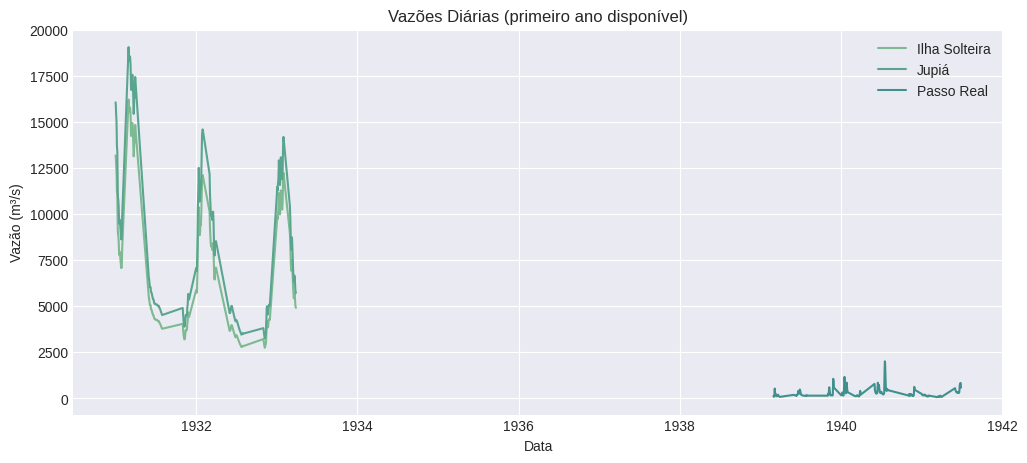

In [ ]:

plt.figure(figsize=(12,5))
for usina in df_vazoes["Usina"].unique():
    amostra = df_vazoes[df_vazoes["Usina"] == usina].head(365)
    plt.plot(amostra["Data"], amostra["Vazao"], label=usina)
plt.legend()
plt.title("Vazões Diárias (primeiro ano disponível)")
plt.xlabel("Data")
plt.ylabel("Vazão (m³/s)")
plt.show()

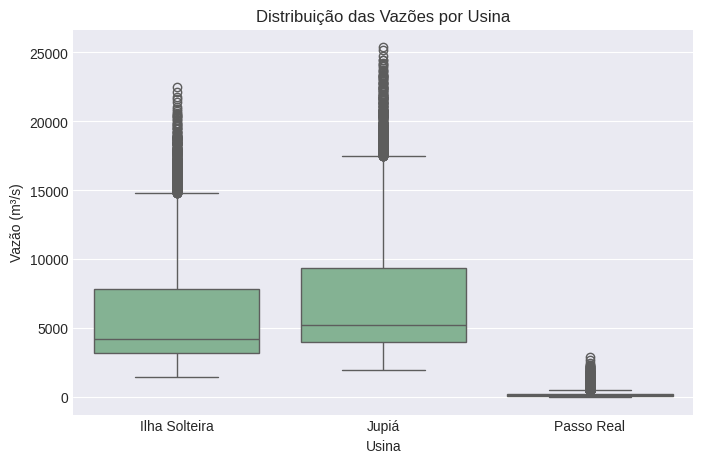

In [ ]:

plt.figure(figsize=(8,5))
sns.boxplot(x="Usina", y="Vazao", data=df_vazoes)
plt.title("Distribuição das Vazões por Usina")
plt.ylabel("Vazão (m³/s)")
plt.show()

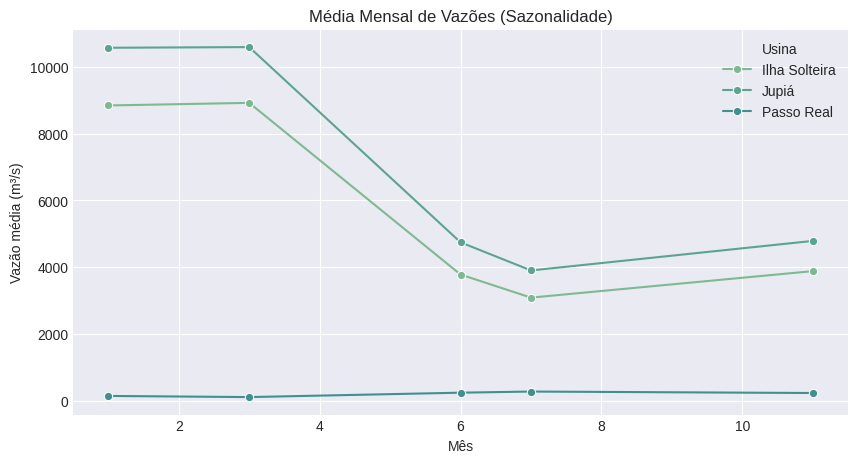

In [ ]:

plt.figure(figsize=(10,5))
sns.lineplot(data=df_vazoes.groupby(["Usina", "Mes"])["Vazao"].mean().reset_index(),
             x="Mes", y="Vazao", hue="Usina", marker="o")
plt.title("Média Mensal de Vazões (Sazonalidade)")
plt.xlabel("Mês")
plt.ylabel("Vazão média (m³/s)")
plt.show()